##**HR Attrition Prediction**

**Problem Statement**
Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
- Age
- Salary
- Job Role
- Job Satisfaction
- Work Experience
- Overtime
- Work-Life Balance
- Department

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('HR_Employee_Attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
data.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
data.shape

(1470, 35)

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
cat_cols = data.select_dtypes(include=['object'])
cat_cols

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [ ]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# check for unique values
for x in cat_cols:
  print(x,'--->',data[x].unique())

Attrition ---> ['Yes' 'No']
BusinessTravel ---> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department ---> ['Sales' 'Research & Development' 'Human Resources']
EducationField ---> ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender ---> ['Female' 'Male']
JobRole ---> ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus ---> ['Single' 'Married' 'Divorced']
Over18 ---> ['Y']
OverTime ---> ['Yes' 'No']


In [ ]:
# check for value counts
for x in cat_cols:
  print(data[x].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
Over18
Y    1470
Name: count,

**Data cleaning**

In [ ]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


##**There are no null values**

In [ ]:
data.duplicated().sum()

np.int64(0)

**Exploratory data analysis**


**Univariate**

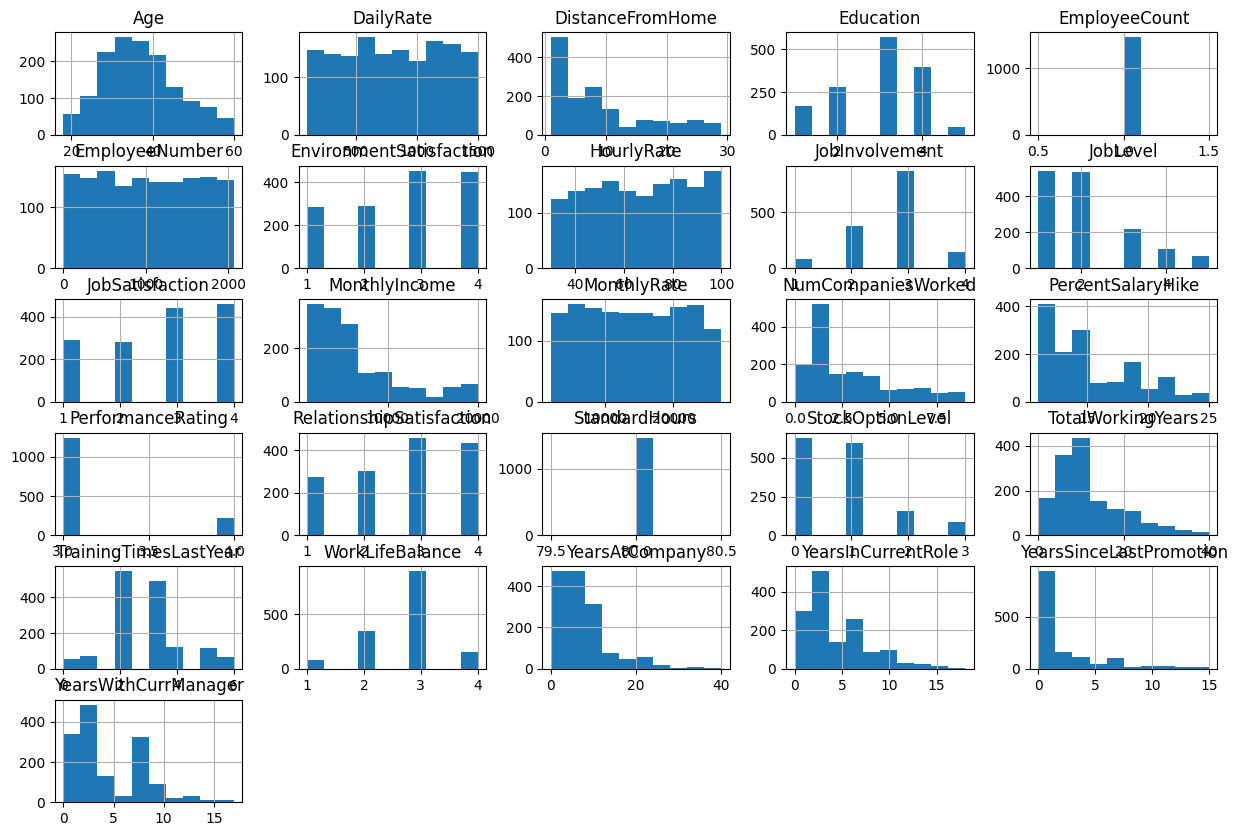

In [ ]:
data.hist(figsize=(15,10))
plt.show()

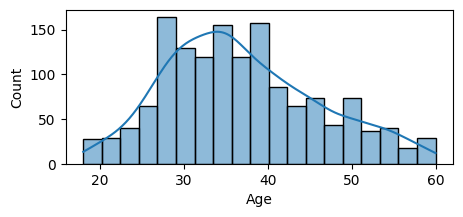

In [ ]:
# check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='Age',kde=True)
plt.show()

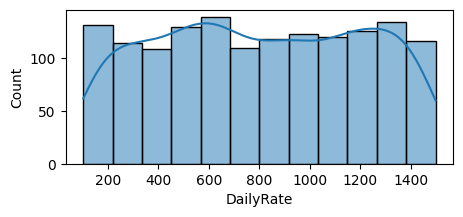

In [ ]:
# check the distribution of DailyRate
plt.figure(figsize=(5,2))
sns.histplot(data,x='DailyRate',kde=True)
plt.show()

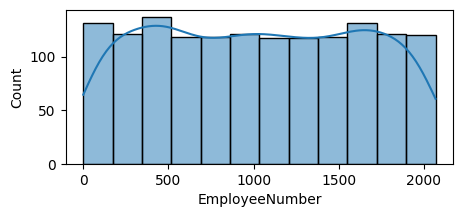

In [ ]:
# check the distribution of EmployeeNumber
plt.figure(figsize=(5,2))
sns.histplot(data,x='EmployeeNumber',kde=True)
plt.show()

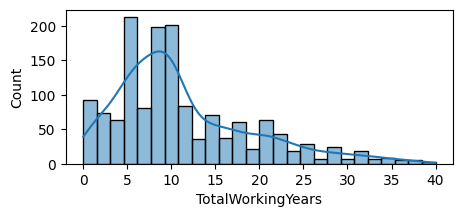

In [ ]:
# check the distribution of TotalWorkingYears
plt.figure(figsize=(5,2))
sns.histplot(data,x='TotalWorkingYears',kde=True)
plt.show()

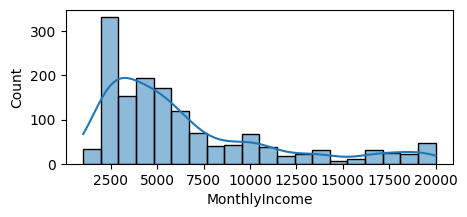

In [ ]:
# check the distribution of MonthlyIncome
plt.figure(figsize=(5,2))
sns.histplot(data,x='MonthlyIncome',kde=True)
plt.show()

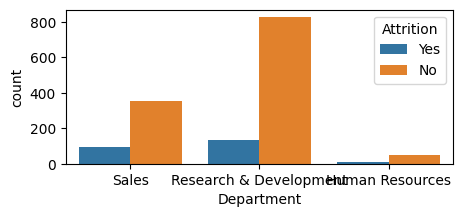

In [ ]:
# Count plot for Department
plt.figure(figsize=(5,2))
sns.countplot(data,x='Department',hue='Attrition')
plt.show()

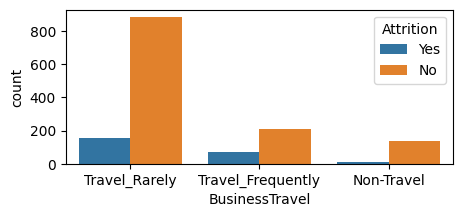

In [ ]:
# Count plot for BusinessTravel
plt.figure(figsize=(5,2))
sns.countplot(data,x='BusinessTravel',hue='Attrition')
plt.show()

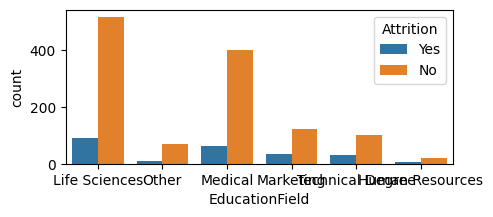

In [ ]:
# Count plot for EducationField
plt.figure(figsize=(5,2))
sns.countplot(data,x='EducationField',hue='Attrition')
plt.show()

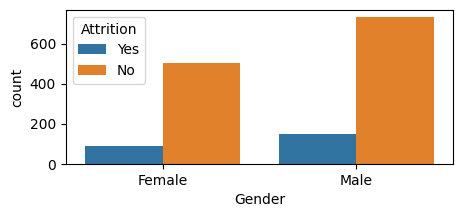

In [ ]:
# Count plot for Gender
plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender',hue='Attrition')
plt.show()

**Bivariate analysis**

**Attrition vs Categorical Features**

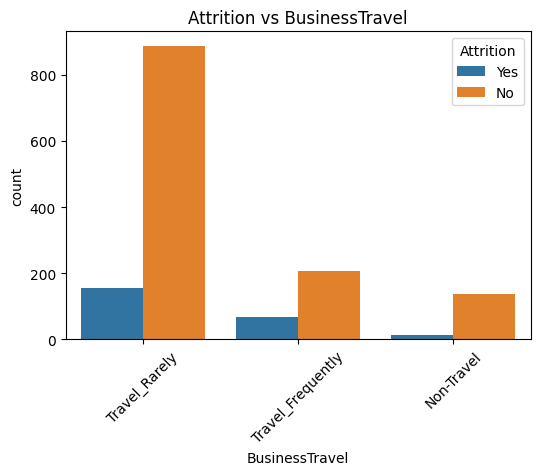

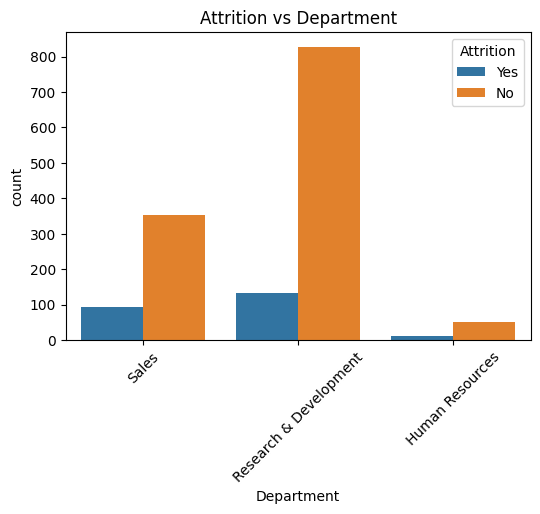

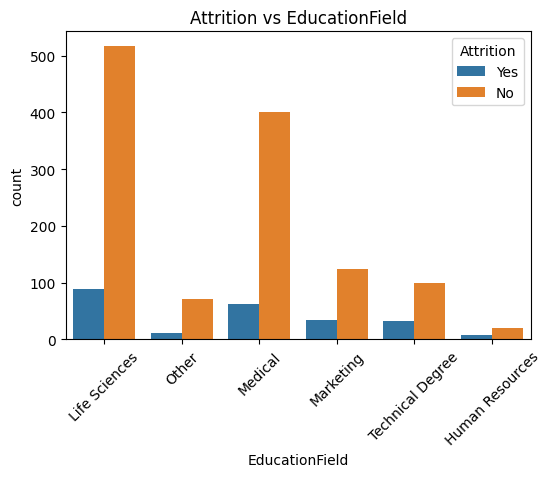

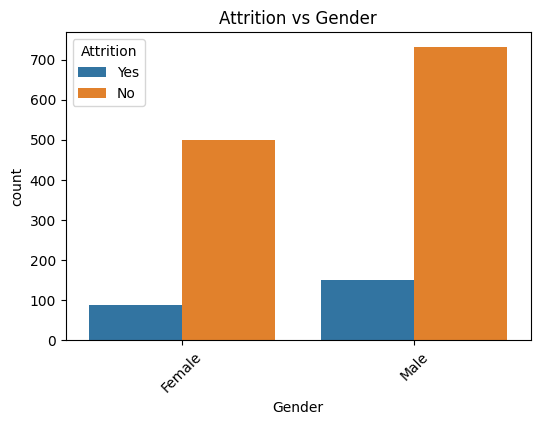

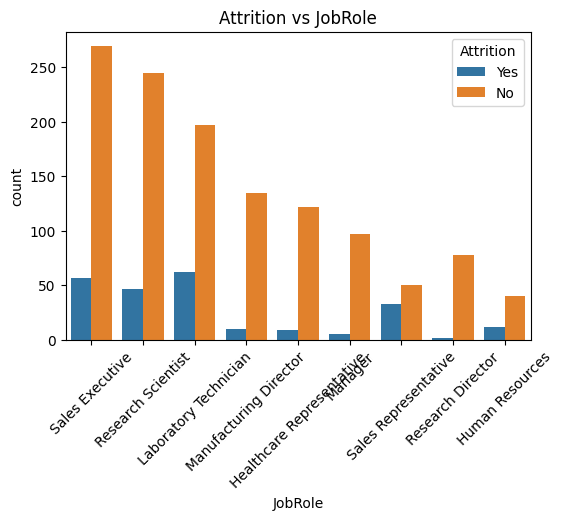

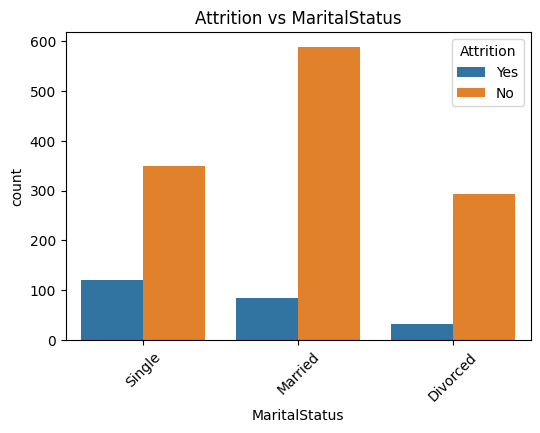

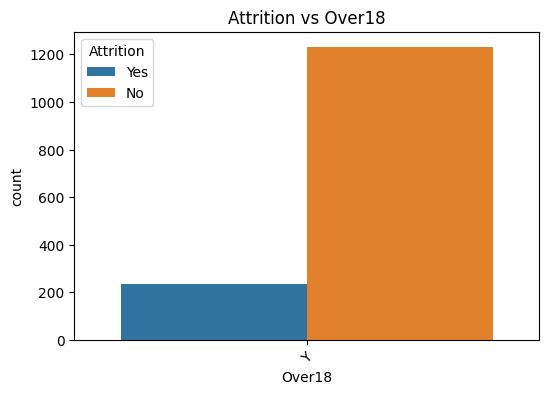

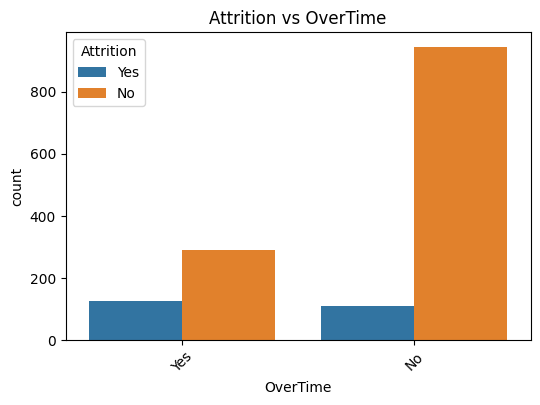

In [ ]:
for col in cat_cols:
    if col != 'Attrition':
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Attrition', data=data)
        plt.title(f'Attrition vs {col}')
        plt.xticks(rotation=45)
        plt.show()

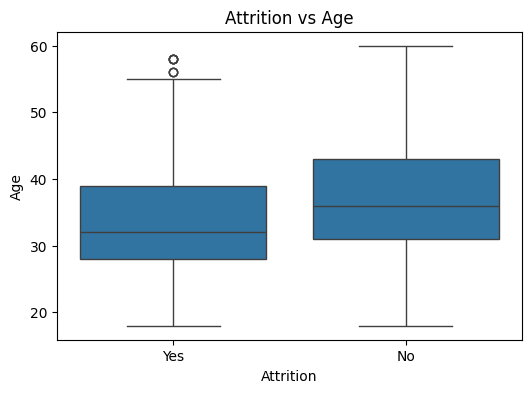

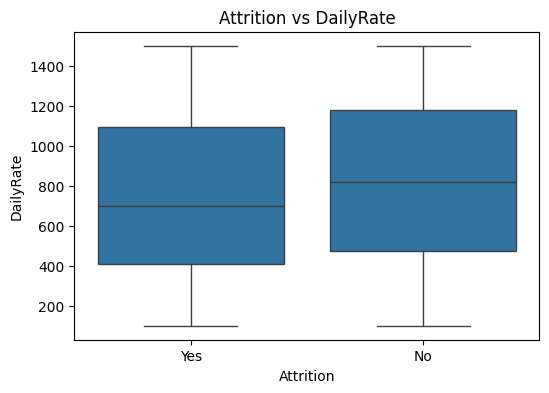

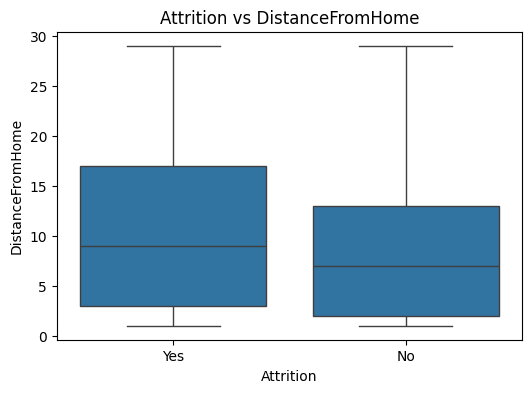

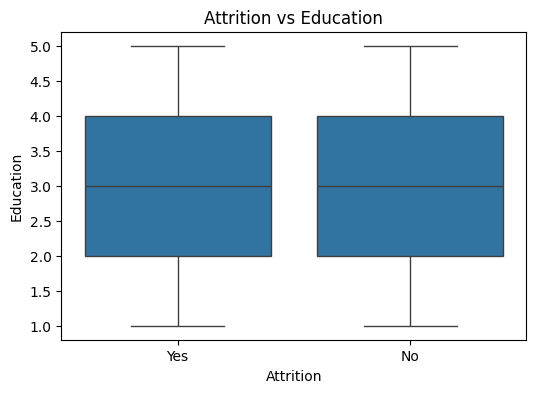

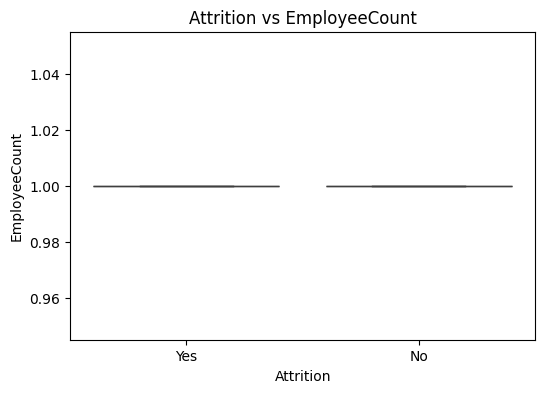

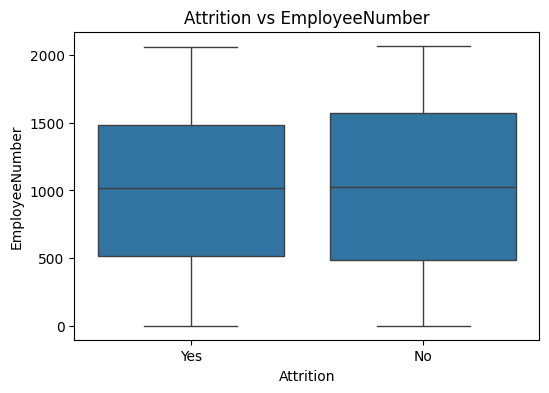

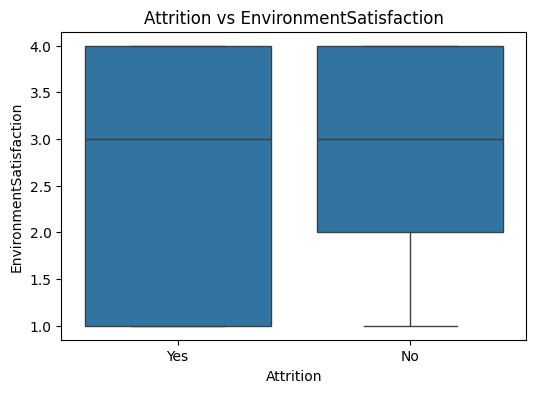

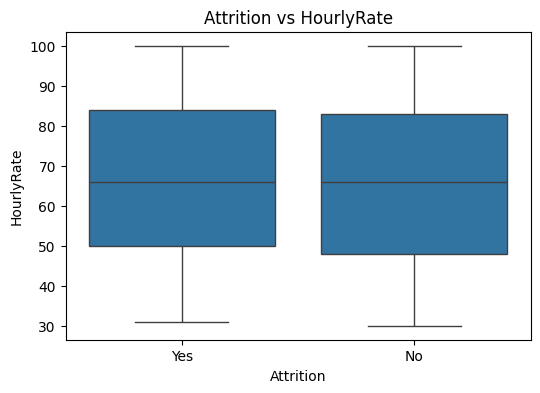

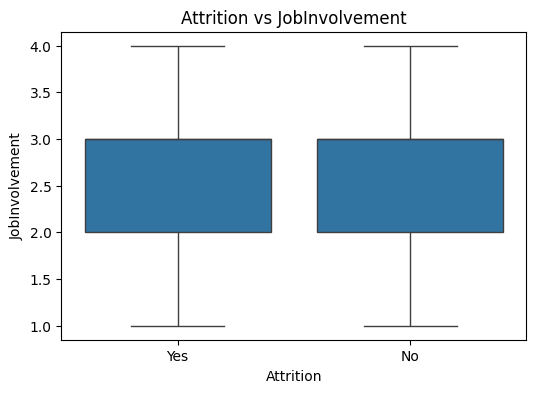

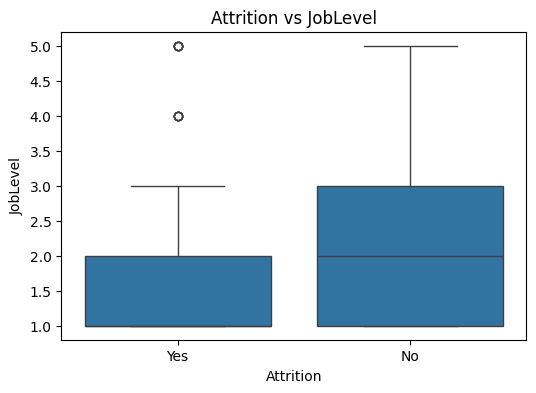

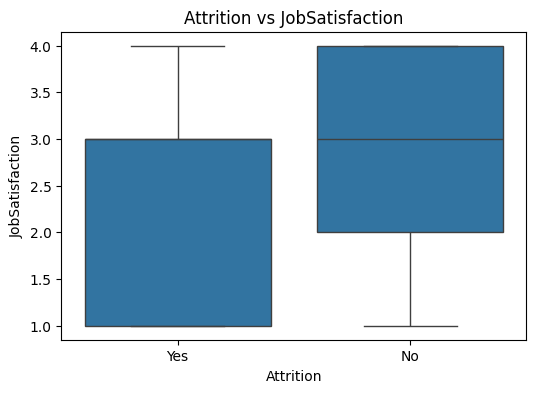

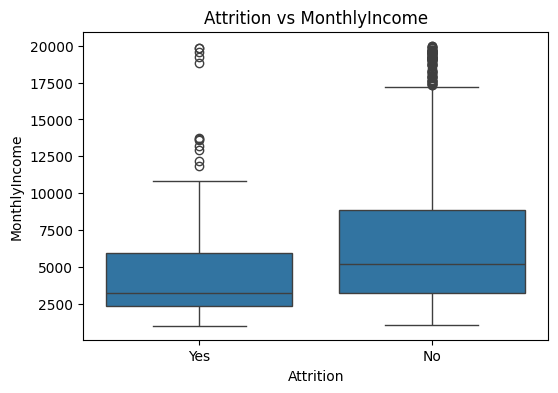

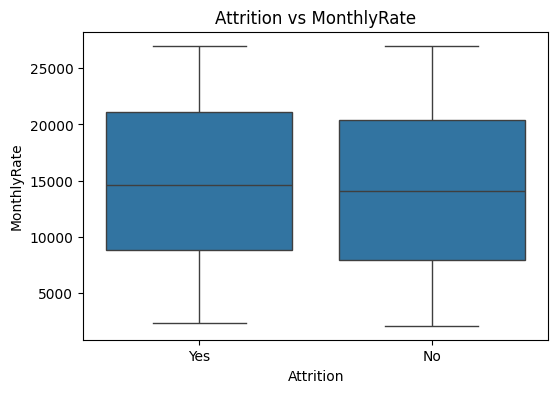

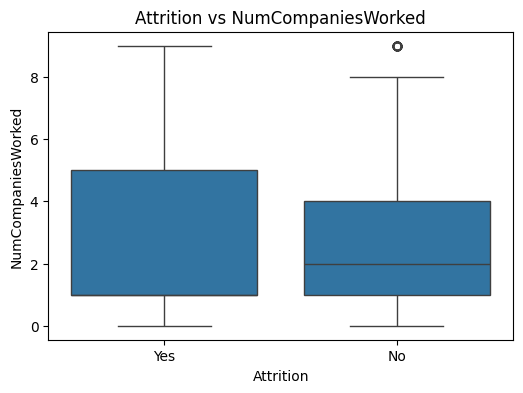

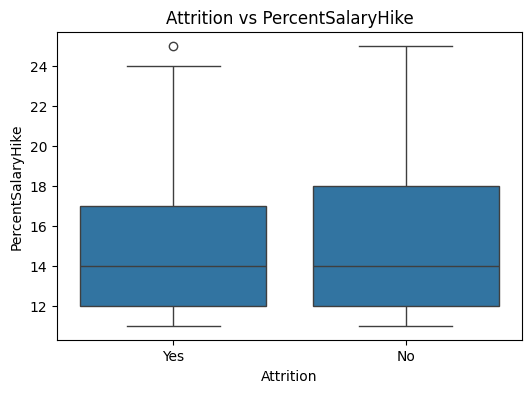

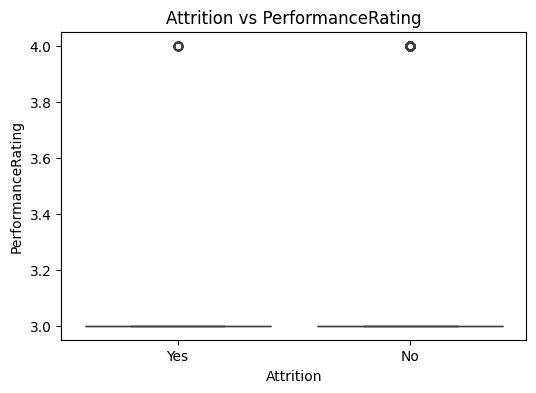

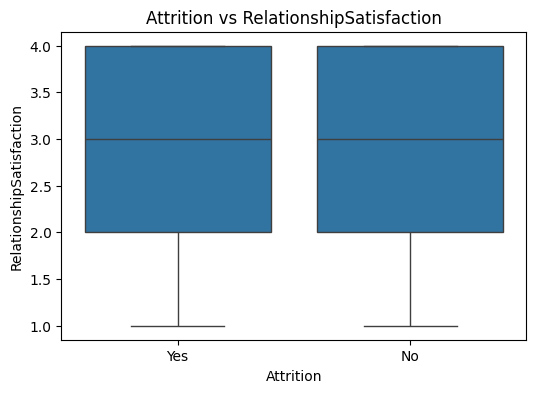

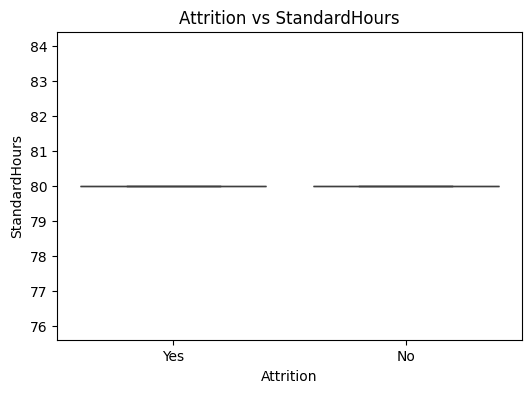

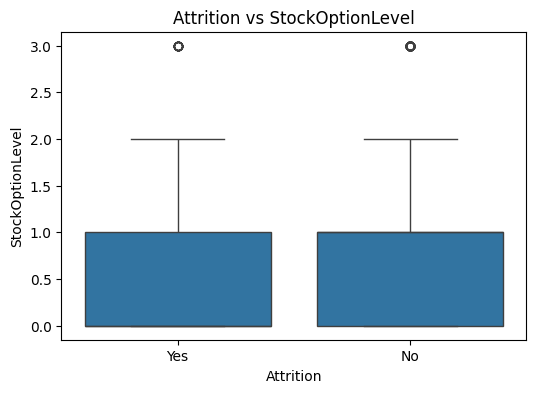

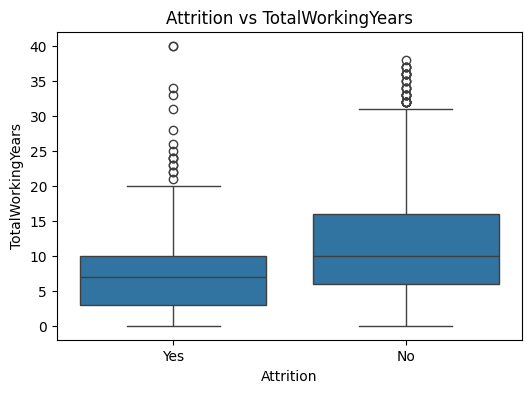

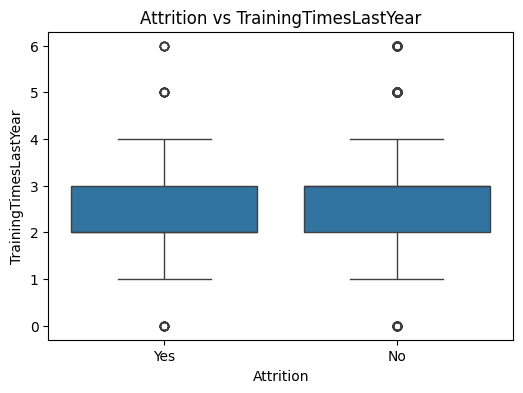

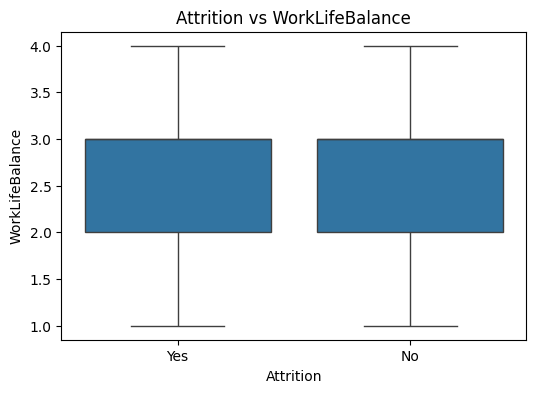

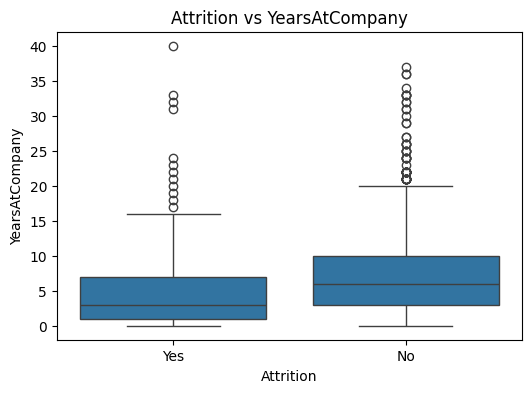

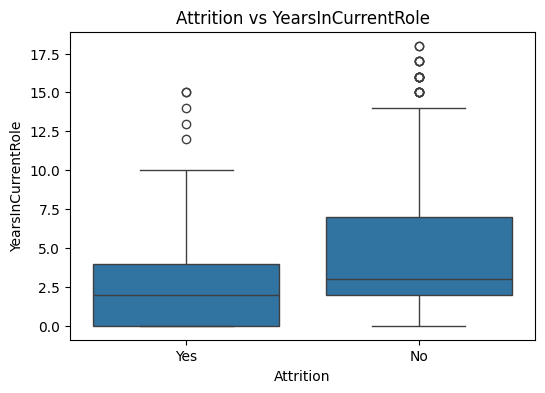

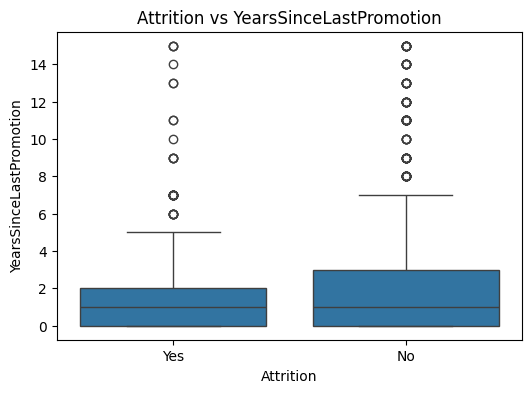

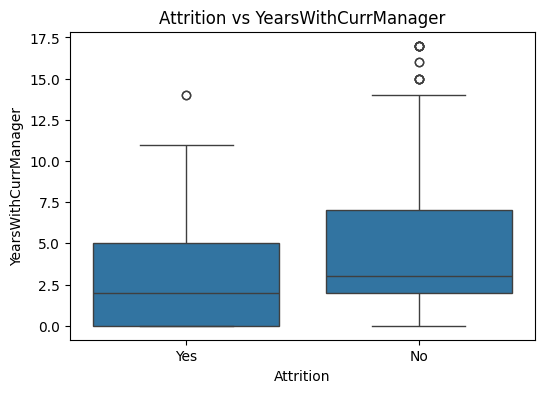

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attrition', y=col, data=data)
    plt.title(f'Attrition vs {col}')
    plt.show()

**Correlation heatmap**

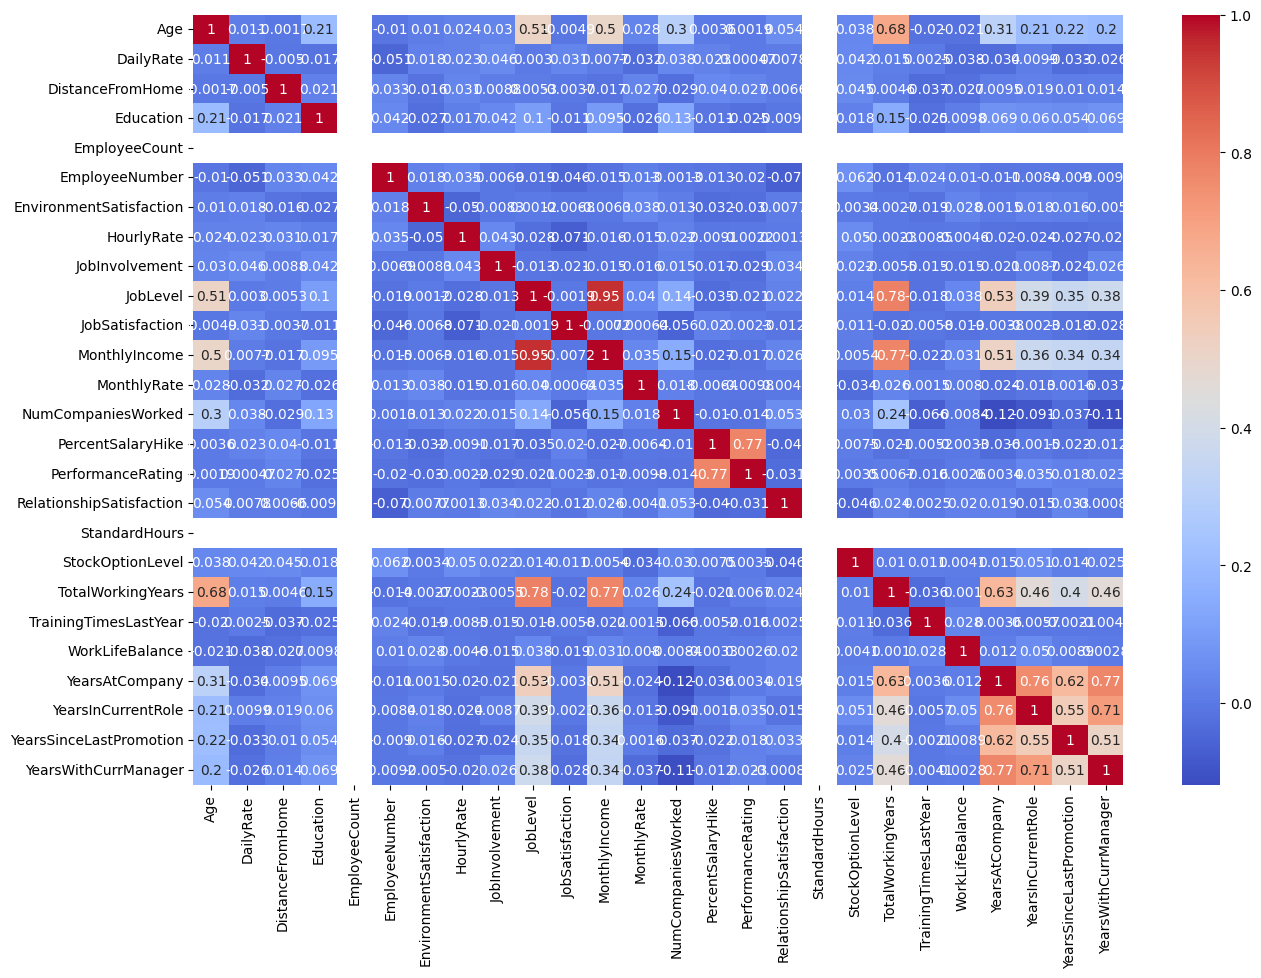

In [ ]:
corr_matrix = num_cols.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

##**Outliers are found in following columns:**
- MonthlyIncome
- NumCompaniesWorked
- PerformanceRating
- StockOptionLevel
- TotalWorkingYears
- TrainingTimesLastYear
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManage

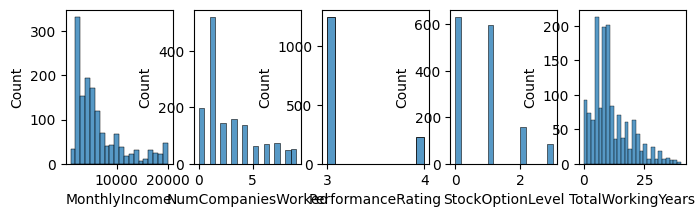

In [ ]:
# check the distribution
fig,ax=plt.subplots(1,5,figsize=(8,2))
sns.histplot(data,x='MonthlyIncome',ax=ax[0])
sns.histplot(data,x='NumCompaniesWorked',ax=ax[1])
sns.histplot(data,x='PerformanceRating',ax=ax[2])
sns.histplot(data,x='StockOptionLevel',ax=ax[3])
sns.histplot(data,x='TotalWorkingYears',ax=ax[4])
plt.show()

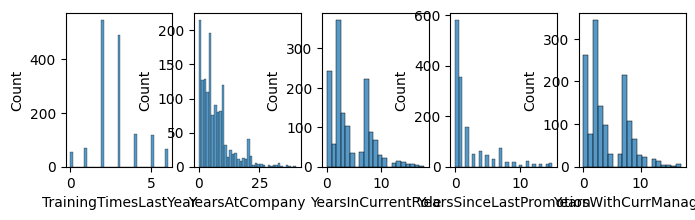

In [ ]:
fig,ax=plt.subplots(1,5,figsize=(8,2))
sns.histplot(data,x='TrainingTimesLastYear',ax=ax[0])
sns.histplot(data,x='YearsAtCompany',ax=ax[1])
sns.histplot(data,x='YearsInCurrentRole',ax=ax[2])
sns.histplot(data,x='YearsSinceLastPromotion',ax=ax[3])
sns.histplot(data,x='YearsWithCurrManager',ax=ax[4])
plt.show()

In [ ]:
df = ['MonthlyIncome','NumCompaniesWorked','PerformanceRating',
      'StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear',
      'YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion',
      'YearsWithCurrManager']
for x in df:
  print(x,'-->',data[x].skew())
  print()

MonthlyIncome --> 1.3698166808390662

NumCompaniesWorked --> 1.026471111968205

PerformanceRating --> 1.921882702142603

StockOptionLevel --> 0.9689803167738937

TotalWorkingYears --> 1.1171718528128527

TrainingTimesLastYear --> 0.5531241710537028

YearsAtCompany --> 1.7645294543422085

YearsInCurrentRole --> 0.9173631562908262

YearsSinceLastPromotion --> 1.9842899833524859

YearsWithCurrManager --> 0.8334509919918475



In [ ]:
#find skew
#skew=[-0.5,0.5]-->normal
#skew>0.5-->rigth skew
#skew<-0.5 --->left skew


In [ ]:
df = ['MonthlyIncome','NumCompaniesWorked','PerformanceRating',
      'StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear',
      'YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion',
      'YearsWithCurrManager']
for col in df:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

In [ ]:
data[(data.loc[:,'MonthlyIncome']>upper)|(data.loc[:,'MonthlyIncome']<lower)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
len(data[(data.loc[:,'MonthlyIncome']>upper)|(data.loc[:,'MonthlyIncome']<lower)])/len(data)*100

100.0

In [ ]:
data[(data.loc[:,'NumCompaniesWorked']>upper)|(data.loc[:,'NumCompaniesWorked']<lower)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
len(data[(data.loc[:,'NumCompaniesWorked']>upper)|(data.loc[:,'NumCompaniesWorked']<lower)])/len(data)*100

0.0

In [ ]:
data[(data.loc[:,'PerformanceRating']>upper)|(data.loc[:,'PerformanceRating']<lower)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
len(data[(data.loc[:,'PerformanceRating']>upper)|(data.loc[:,'PerformanceRating']<lower)])/len(data)*100

0.0

In [ ]:
data[(data.loc[:,'TotalWorkingYears']>upper)|(data.loc[:,'TotalWorkingYears']<lower)]
len(data[(data.loc[:,'TotalWorkingYears']>upper)|(data.loc[:,'TotalWorkingYears']<lower)])/len(data)*100

26.93877551020408

In [ ]:
data[(data.loc[:,'TrainingTimesLastYear']>upper)|(data.loc[:,'TrainingTimesLastYear']<lower)]
len(data[(data.loc[:,'TrainingTimesLastYear']>upper)|(data.loc[:,'TrainingTimesLastYear']<lower)])/len(data)*100

0.0

In [ ]:
data[(data.loc[:,'YearsAtCompany']>upper)|(data.loc[:,'YearsAtCompany']<lower)]
len(data[(data.loc[:,'YearsAtCompany']>upper)|(data.loc[:,'YearsAtCompany']<lower)])/len(data)*100

10.748299319727892

In [ ]:
data[(data.loc[:,'YearsInCurrentRole']>upper)|(data.loc[:,'YearsInCurrentRole']<lower)]
len(data[(data.loc[:,'YearsInCurrentRole']>upper)|(data.loc[:,'YearsInCurrentRole']<lower)])/len(data)*100

1.4285714285714286

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'YearsInCurrentRole']>upper)|
 (data.loc[:,'YearsInCurrentRole']<lower),'YearsInCurrentRole']=data.loc[:,'YearsInCurrentRole'].median()

In [ ]:
len(data[(data.loc[:,'YearsInCurrentRole']>upper)|(data.loc[:,'YearsInCurrentRole']<lower)])/len(data)*100

0.0

In [ ]:
data[(data.loc[:,'YearsSinceLastPromotion']>upper)|(data.loc[:,'YearsSinceLastPromotion']<lower)]
len(data[(data.loc[:,'YearsSinceLastPromotion']>upper)|(data.loc[:,'YearsSinceLastPromotion']<lower)])/len(data)*100

0.8843537414965987

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'YearsSinceLastPromotion']>upper)|
 (data.loc[:,'YearsSinceLastPromotion']<lower),'YearsSinceLastPromotion']=data.loc[:,'YearsSinceLastPromotion'].median()

In [ ]:
len(data[(data.loc[:,'YearsSinceLastPromotion']>upper)|(data.loc[:,'YearsSinceLastPromotion']<lower)])/len(data)*100

0.0

In [ ]:
data[(data.loc[:,'YearsWithCurrManager']>upper)|(data.loc[:,'YearsWithCurrManager']<lower)]
len(data[(data.loc[:,'YearsWithCurrManager']>upper)|(data.loc[:,'YearsWithCurrManager']<lower)])/len(data)*100

0.9523809523809524

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'YearsWithCurrManager']>upper)|
 (data.loc[:,'YearsWithCurrManager']<lower),'YearsWithCurrManager']=data.loc[:,'YearsWithCurrManager'].median()

In [ ]:
len(data[(data.loc[:,'YearsWithCurrManager']>upper)|(data.loc[:,'YearsWithCurrManager']<lower)])/len(data)*100

0.0

##**Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['Attrition'] = le.fit_transform(data['Attrition'])
data['Gender'] = le.fit_transform(data['Gender'])
data['OverTime'] = le.fit_transform(data['OverTime'])

In [ ]:
data = pd.get_dummies(data, columns=['BusinessTravel'], drop_first=True)

data = pd.get_dummies(data, columns=['Department'], drop_first=True)

data = pd.get_dummies(data, columns=['EducationField'], drop_first=True)

data = pd.get_dummies(data, columns=['JobRole'], drop_first=True)

data = pd.get_dummies(data, columns=['MaritalStatus'], drop_first=True)

In [ ]:
data = data.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features & target
X = data.drop('Attrition', axis=1)
y = data['Attrition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##**Balancing data**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_sm, y_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_sm.value_counts())

Before SMOTE: Attrition
0    978
1    198
Name: count, dtype: int64
After SMOTE: Attrition
0    978
1    978
Name: count, dtype: int64


**Logistic regression**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
#Training the model
lr = LogisticRegression(max_iter=1000)
lr.fit(x_sm, y_sm)
y_pred_lr = lr.predict(X_test)
#Model evaluation
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression
Accuracy: 0.7585034013605442
Precision: 0.2894736842105263
Recall: 0.5641025641025641
F1 Score: 0.3826086956521739
ROC-AUC: 0.7413775766716943


**Decision tree clasifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_sm, y_sm)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

Decision Tree
Accuracy: 0.7925170068027211
Precision: 0.23809523809523808
Recall: 0.2564102564102564
F1 Score: 0.24691358024691357
ROC-AUC: 0.5654600301659125


In [152]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',
                               max_depth=60,max_features='sqrt',
                               splitter='best',min_samples_leaf=5,
                               min_samples_split=6,random_state=42)
model.fit(x_sm,y_sm)
y_pred = model.predict(X_test)

In [153]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[215  40]
 [ 28  11]]
Accuracy:  0.7687074829931972
Recall:  0.28205128205128205
Precision:  0.21568627450980393
f1_score:  0.24444444444444444


**Random forest classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_sm, y_sm)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest
Accuracy: 0.8707482993197279
Precision: 0.5384615384615384
Recall: 0.1794871794871795
F1 Score: 0.2692307692307692
ROC-AUC: 0.7421820010055304


In [166]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=15,max_depth=50,
                               bootstrap=True,criterion='gini',
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5)
model.fit(x_sm,y_sm)
y_pred = model.predict(X_test)

In [167]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[240  15]
 [ 27  12]]
Accuracy:  0.8571428571428571
Recall:  0.3076923076923077
Precision:  0.4444444444444444
f1_score:  0.36363636363636365


**KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_sm, y_sm)

y_pred_knn = knn.predict(X_test)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]))

KNN
Accuracy: 0.673469387755102
Precision: 0.22857142857142856
Recall: 0.6153846153846154
F1 Score: 0.3333333333333333
ROC-AUC: 0.6707893413775767


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(name, y_test, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [147]:
results = []

# Logistic Regression
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, lr.predict_proba(X_test)[:,1]))

# Decision Tree
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt, dt.predict_proba(X_test)[:,1]))

# Random Forest
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, rf.predict_proba(X_test)[:,1]))

# KNN
results.append(evaluate_model("KNN", y_test, y_pred_knn, knn.predict_proba(X_test)[:,1]))

In [148]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.758503   0.289474  0.564103  0.382609  0.741378
3                  KNN  0.673469   0.228571  0.615385  0.333333  0.670789
2        Random Forest  0.870748   0.538462  0.179487  0.269231  0.742182
1        Decision Tree  0.792517   0.238095  0.256410  0.246914  0.565460


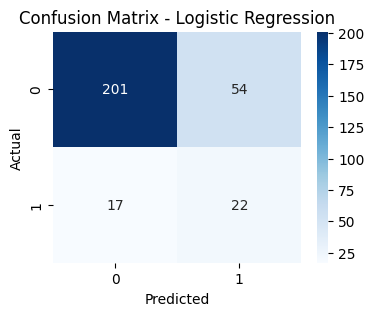

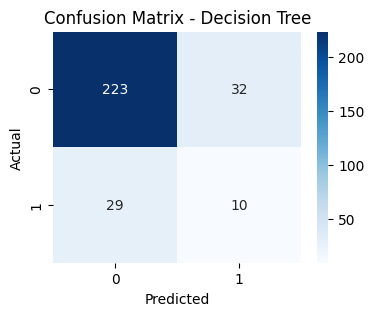

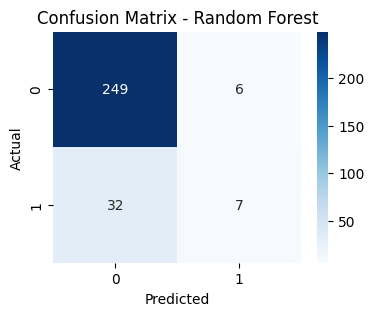

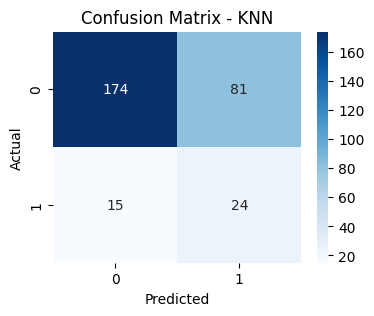

In [149]:
import seaborn as sns

models = {
    "Logistic Regression": (y_pred_lr),
    "Decision Tree": (y_pred_dt),
    "Random Forest": (y_pred_rf),
    "KNN": (y_pred_knn)
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()